In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [3]:
ch_client = clickhouse_connect.get_client(
    host="127.0.0.1", 
    port="8123",
    database="BENCHMARK_DATASETS",
    username="BENCHMARK_DWH_PRODUCER_USER", 
    password="benchmarkdwhproducer001$:"
)

In [8]:
query = """
SELECT 
    PCLASS, 
    AGE_NORM,
    SIBLING_SPOUSE_ABOARD,
    PARCH,
    FARE,
    SEX,
    PCLASS_1,
    PCLASS_2,
    PCLASS_3, 
    EMBARKED_S, 
    EMBARKED_C,
    EMBARKED_Q,
    SURVIVED
    FROM TITANIC_FEATURES
"""
records = ch_client.query(query)
results = records.result_rows
df = pd.DataFrame(records.result_rows, columns=records.column_names)
df

,PCLASS,AGE_NORM,SIBLING_SPOUSE_ABOARD,PARCH,FARE,SEX,PCLASS_1,PCLASS_2,PCLASS_3,EMBARKED_S,EMBARKED_C,EMBARKED_Q,SURVIVED
0,3,0.271174,0.2,0.000000,0.014151,0,0,0,1,1,0,0,0
1,1,0.472229,0.2,0.000000,0.139136,1,1,0,0,0,1,0,1
2,3,0.321438,0.0,0.000000,0.015469,1,0,0,1,1,0,0,1
3,1,0.434531,0.2,0.000000,0.103644,1,1,0,0,1,0,0,1
4,3,0.434531,0.0,0.000000,0.015713,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,3,0.484795,0.0,0.833333,0.056848,1,0,0,1,0,0,1,0
710,2,0.334004,0.0,0.000000,0.025374,0,0,1,0,1,0,0,0
711,1,0.233476,0.0,0.000000,0.058556,1,1,0,0,1,0,0,1
712,1,0.321438,0.0,0.000000,0.058556,0,1,0,0,0,1,0,1


In [30]:
X = df[['PCLASS', 'AGE_NORM', 'SIBLING_SPOUSE_ABOARD', 'PARCH', 'FARE', 'SEX', 'PCLASS_1', 'PCLASS_2', 'EMBARKED_S', 'EMBARKED_C', 'EMBARKED_Q']]
y = df[['SURVIVED']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=29
)

In [31]:
model = LogisticRegression(max_iter=1000, solver='saga')
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of 

In [32]:
y_pred = model.predict(X_test)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7988826815642458

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[80, 18],
       [18, 63]])

In [22]:
precision = precision_score(y_test, y_pred)
f"Precision: {round(precision,2)}"

'Precision: 0.78'

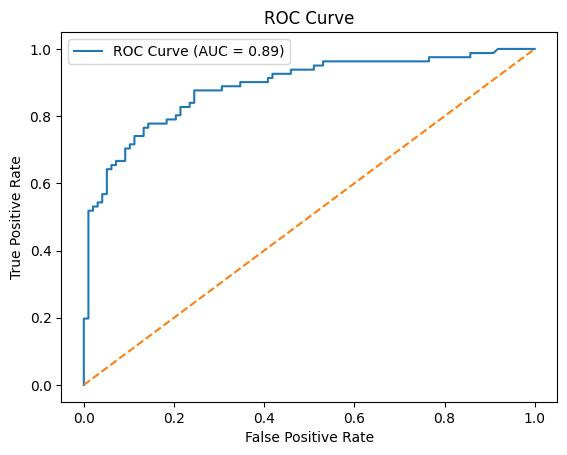

In [23]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()